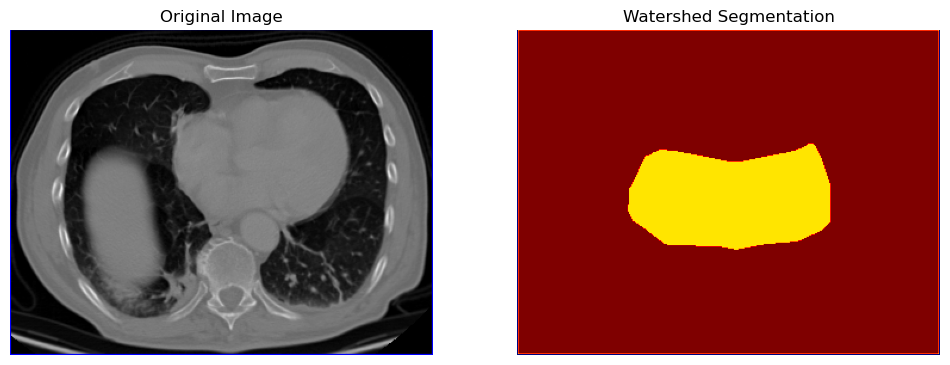

Watershed segmentation completed. Check the output image.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the CT scan image
image_path = '000122.png'  # Update with your image path
image = cv2.imread(image_path)

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Perform edge detection using Canny
edges = cv2.Canny(blurred, 50, 150)

# Dilate the edges to close gaps
dilated_edges = cv2.dilate(edges, None, iterations=2)

# Find contours in the dilated edges
contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a mask for the sure foreground area
mask = np.zeros(gray.shape, dtype=np.uint8)

# Fill the contours on the mask
for contour in contours:
    cv2.drawContours(mask, [contour], -1, 255, -1)

# Perform distance transform
dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Find unknown region (background)
unknown = cv2.subtract(mask, sure_fg.astype(np.uint8))

# Label markers for watershed
markers = np.zeros_like(gray, dtype=np.int32)
markers[sure_fg.astype(np.uint8) == 255] = 1
markers[unknown == 255] = 2

# Apply the Watershed algorithm
cv2.watershed(image, markers)

# Mark the boundaries on the original image
image[markers == -1] = [255, 0, 0]  # Mark edges in red

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Watershed Segmentation')
plt.imshow(markers, cmap='jet')
plt.axis('off')

plt.show()

# Save the result (optional)
output_path = 'watershed_output.png'  # Path to save the segmented image
cv2.imwrite(output_path, image)

print("Watershed segmentation completed. Check the output image.")
